In [ ]:
from collections.abc import Sequence
import itertools
from itertools import chain, combinations
from json import load
import os
import sys

sys.path.append(os.path.abspath('../src'))

import catboost

import joblib
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks,\
                                plot, margins
import numpy as np
import polars as pl
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score,\
                            confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

from feature_extractor import FeatureExtractor

In [2]:
SEED = 42


In [3]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    )


# Приготовления

## Разбиение на фолды

In [4]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

for _, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    display(big_y_raw[val_indices]\
            .value_counts()\
            .sort('count', descending=True))
                                        

error_type_label,count
i64,u32
0,2967
4,173
3,62
7,51
6,28
2,19
5,11
1,4


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,50
6,28
2,19
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,27
2,19
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,28
2,18
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,28
2,18
5,12
1,5


In [ ]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor(
    stop_words=('нрзб',),
    search_stop_words=('это',),
    word_list_n_candidates=200,
    word_list_radius=10,
    ruwordnet_n_candidates=200,
    ruwordnet_n_best=10
)

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train: list[tuple[pl.DataFrame, pl.Series]] = []
folds_val: list[tuple[pl.DataFrame, pl.Series]] = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))
    assert (folds_train[-1][0].sum_horizontal().sum() * 0) == 0
    assert (folds_train[-1][0].null_count().sum_horizontal().sum()) == 0


1462it [00:16, 90.05it/s] 
702it [00:08, 86.50it/s] 
1448it [00:18, 77.85it/s] 
679it [00:06, 97.18it/s] 
1191it [00:13, 91.04it/s]


KeyboardInterrupt: 

In [ ]:
joblib.dump((folds_train, folds_val), 'features.joblib.xz', 9)


['features.joblib.xz']

In [4]:
folds_train, folds_val = joblib.load('features.joblib.xz')


## Функция для оценивания

In [ ]:
error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


In [ ]:
def evaluate(model: BaseEstimator,
    folds_train: list[tuple[pl.DataFrame, pl.Series]] = folds_train,
    folds_val: list[tuple[pl.DataFrame, pl.Series]] = folds_val,
    error_type_ids_to_names: list[str] = error_type_ids_to_names,
    *,
    include_classes: set[int] | None = None,
    merge_classes: list[int] | None = None,
    merge_classes_names: list[str] | None = None,
    supress_plot: bool = False,
    supress_print: bool = False,
    include_features: list[str] | None = None,
    exclude_features: list[str] | None = None,
    output_separate_f1s: bool = False):

    assert len(folds_train) == len(folds_val)
    number_of_folds: int = len(folds_train)
    classes_present: set[int] = {
                                   label 
                                   for _, y_val in folds_val 
                                   for label in y_val.unique().to_list()
                                }
    
    if include_classes:
        classes_present &= include_classes
    else:
        include_classes = classes_present

    if merge_classes:
        classes_present = {merge_classes[class_]
                           for class_ in classes_present}
        if merge_classes_names:
            error_type_ids_to_names = merge_classes_names
        else:
            error_type_ids_to_names = [f'Класс {i}'
                                for i
                                in range(len(error_type_ids_to_names))]
    else:
        merge_classes = [-1] * (max(classes_present) + 1)
        for class_ in classes_present:
            merge_classes[class_] = class_

    classes_present_names: list[str] = [error_type_ids_to_names[i]
                                        for i in classes_present]
    number_of_classes: int = len(classes_present)

    f1s = np.zeros((number_of_folds, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((number_of_folds,
                                   number_of_classes, 
                                   number_of_classes))
    
    for i, (fold_train, fold_val)\
                        in tqdm(enumerate(zip(folds_train, folds_val)), 
                                disable=supress_print):
        X_train, y_train = fold_train
        train_mask = y_train.is_in(include_classes)
        X_train, y_train = X_train.filter(train_mask),\
                                        y_train.filter(train_mask)
        y_train = pl.Series(merge_classes).gather(y_train)
        if include_features:
            X_train = X_train.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_train = X_train.select(
                pl.exclude(*exclude_features)
            )
        model.fit(X_train, y_train)

        X_val, y_val = fold_val
        val_mask = y_val.is_in(include_classes)
        X_val, y_val = X_val.filter(val_mask), y_val.filter(val_mask)
        y_val = pl.Series(merge_classes).gather(y_val)
        if include_features:
            X_val = X_val.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_val = X_val.select(
                pl.exclude(*exclude_features)
            )
        predictions = model.predict(X_val)

        precisions[i] = precision_score(y_val, predictions,
                                         average=None,
                                                zero_division=0)
        recalls[i] = recall_score(y_val, predictions, average=None,
                                                zero_division=0)
        f1s[i] = f1_score(y_val, predictions, average=None,
                                                zero_division=0)
        confusion_matrices[i] = confusion_matrix(y_val, predictions,
                                                 normalize='true')
        
    np.set_printoptions(suppress=True)

    if not supress_print:
        print('Класс\t\t\tPrecision\tRecall\t\tF1')
        print(*('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{name:<24}',
                precision_m.item(),
                precision_s.item(),
                recall_m.item(),
                recall_s.item(),
                f1_m.item(),
                f1_s.item())
                for name, precision_m, precision_s,
                        recall_m, recall_s, 
                        f1_m, f1_s
                in zip(classes_present_names,
                    precisions.mean(axis=0),
                    precisions.std(axis=0),
                    recalls.mean(axis=0),
                    recalls.std(axis=0),
                    f1s.mean(axis=0),
                    f1s.std(axis=0))), 
                sep='\n')
        print('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{'По всем':<24}',
                precisions.mean(axis=1).mean(),
                precisions.std(axis=1).std(),
                recalls.mean(axis=1).mean(),
                recalls.std(axis=1).std(),
                f1s.mean(axis=1).mean(),
                f1s.mean(axis=1).std()))
    
    if not supress_plot:
        imshow(confusion_matrices.mean(axis=0))
        ylabel('Истина')
        xlabel('Предсказание')
        yticks(range(number_of_classes), classes_present_names)
        xticks(range(number_of_classes), classes_present_names, 
            rotation=45)

    if output_separate_f1s:
        return f1s.mean(axis=0)
    return f1s.mean(axis=1).mean()


### Проверка функции для оценивания

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.86±0.13	0.75±0.19	0.77±0.12
аномия                  0.72±0.04	0.71±0.10	0.71±0.07
дизартрия               0.39±0.08	0.16±0.04	0.23±0.05
задержка                0.70±0.03	0.38±0.01	0.50±0.01
поиск слова             0.46±0.09	0.36±0.13	0.39±0.11
семантическая парафазия 0.33±0.08	0.29±0.11	0.31±0.09
фонетическая парафазия  0.64±0.06	0.42±0.05	0.50±0.03
По всем                 0.63±0.02	0.51±0.03	0.55±0.03


np.float64(0.5465690904045623)

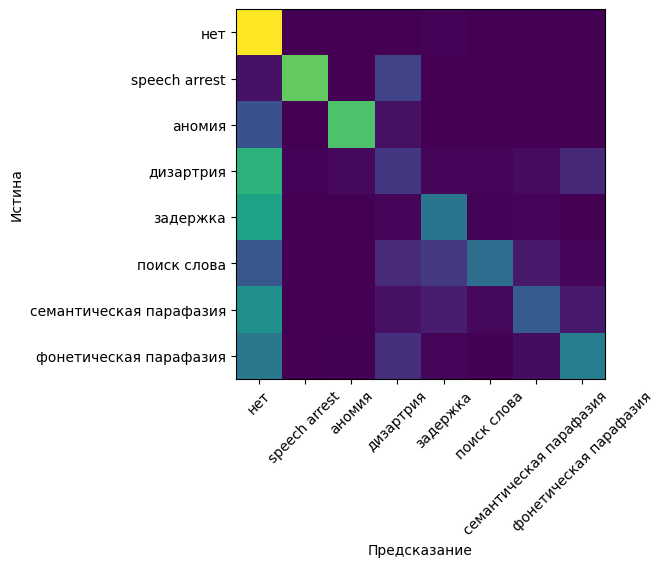

In [26]:
evaluate(DecisionTreeClassifier(max_depth=10))


Класс			Precision	Recall		F1
нет                     0.97±0.00	0.99±0.00	0.98±0.00
задержка                0.69±0.04	0.43±0.02	0.53±0.02
По всем                 0.83±0.02	0.71±0.01	0.75±0.01


np.float64(0.7549813762472961)

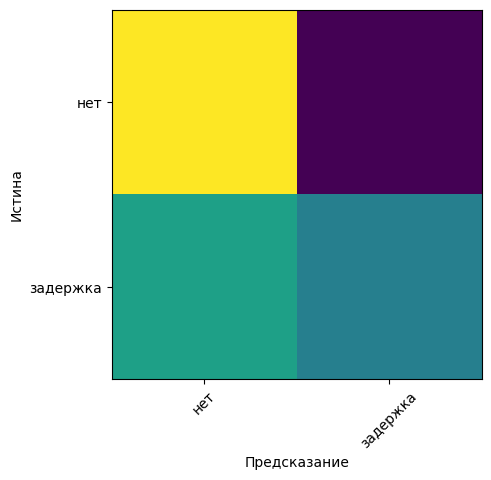

In [27]:
evaluate(DecisionTreeClassifier(max_depth=10), include_classes={0,4})


Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
есть                    0.77±0.02	0.52±0.02	0.62±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7918781077982685)

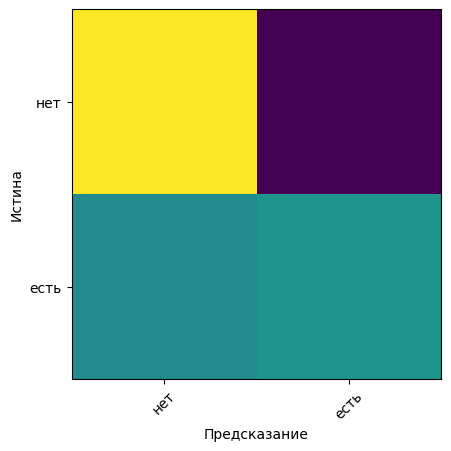

In [28]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1],
         merge_classes_names=['нет', 'есть'])


Класс			Precision	Recall		F1
Класс 0                 0.95±0.00	0.98±0.00	0.96±0.00
Класс 1                 0.77±0.02	0.52±0.02	0.62±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7918781077982685)

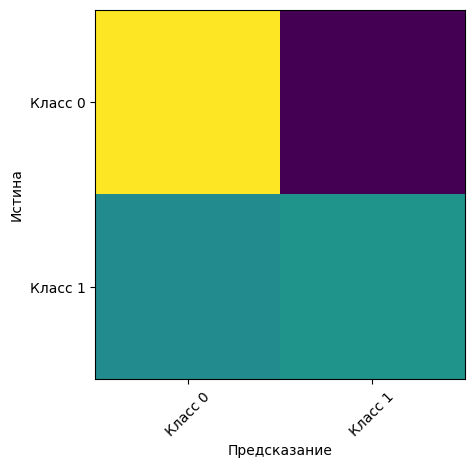

In [29]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1])


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

Класс			Precision	Recall		F1
нет                     0.90±0.00	1.00±0.00	0.95±0.00
speech arrest           0.00±0.00	0.00±0.00	0.00±0.00
аномия                  0.78±0.20	0.39±0.09	0.51±0.11
дизартрия               0.40±0.39	0.01±0.01	0.02±0.02
задержка                0.00±0.00	0.00±0.00	0.00±0.00
поиск слова             0.00±0.00	0.00±0.00	0.00±0.00
семантическая парафазия 0.78±0.22	0.12±0.03	0.21±0.05
фонетическая парафазия  0.70±0.18	0.09±0.04	0.15±0.06
По всем                 0.44±0.02	0.20±0.01	0.23±0.02


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


np.float64(0.23049056942445673)

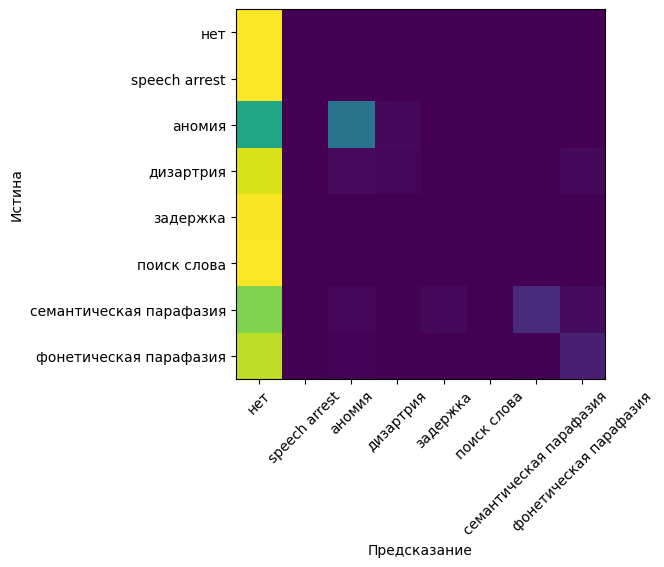

In [32]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[а-яё ].+$'])

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.78±0.12	0.75±0.19	0.74±0.11
аномия                  0.68±0.03	0.72±0.10	0.70±0.05
дизартрия               0.39±0.06	0.15±0.03	0.22±0.04
задержка                0.69±0.03	0.39±0.02	0.50±0.02
поиск слова             0.42±0.06	0.39±0.12	0.39±0.08
семантическая парафазия 0.34±0.07	0.28±0.11	0.30±0.10
фонетическая парафазия  0.64±0.02	0.42±0.06	0.50±0.04
По всем                 0.61±0.01	0.51±0.03	0.54±0.02


np.float64(0.5397632891938822)

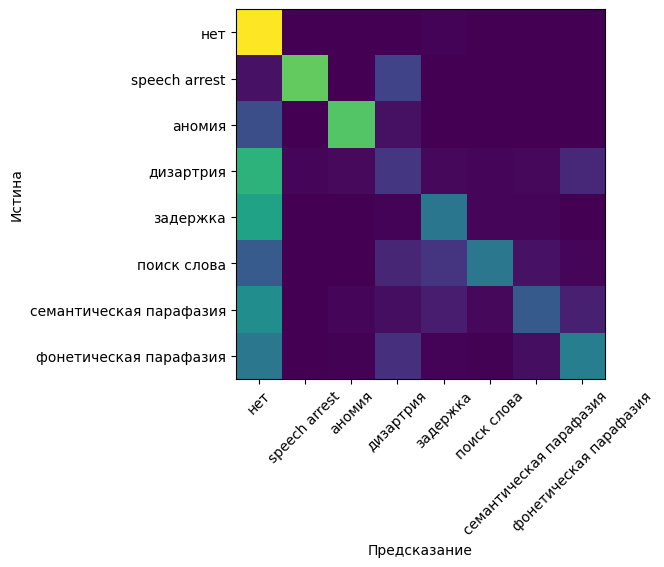

In [34]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[^а-яё ].+$'])


5it [00:03,  1.51it/s]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.83±0.15	0.70±0.22	0.72±0.11
аномия                  0.67±0.04	0.71±0.10	0.69±0.06
дизартрия               0.37±0.06	0.16±0.04	0.22±0.05
задержка                0.70±0.03	0.39±0.01	0.50±0.02
поиск слова             0.47±0.08	0.37±0.10	0.41±0.10
семантическая парафазия 0.35±0.07	0.28±0.11	0.31±0.10
фонетическая парафазия  0.64±0.04	0.42±0.06	0.50±0.04
По всем                 0.62±0.02	0.50±0.03	0.54±0.02


array([0.96336337, 0.72034632, 0.68844552, 0.22141727, 0.49747494,
       0.40989774, 0.30629362, 0.50126658])

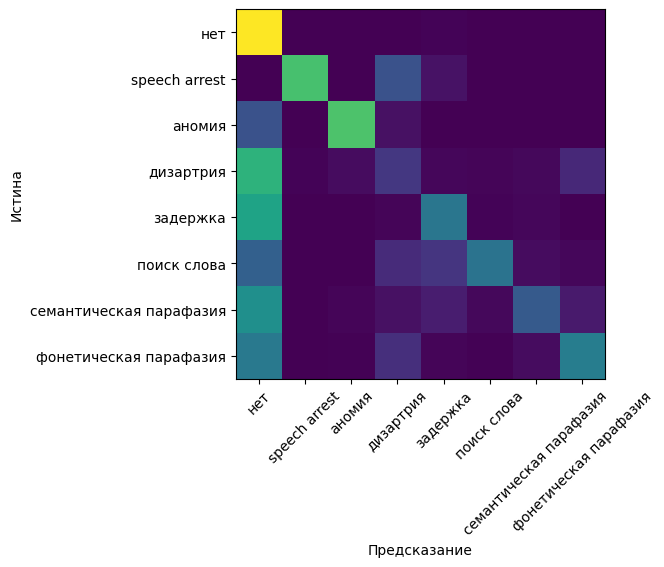

In [83]:
evaluate(DecisionTreeClassifier(max_depth=10),
         output_separate_f1s=True)


# Бейзлайн

Просто решающее дерево с подобранной глубиной не больше 13 ($2^{13} = 8192$, в обучающих фолдах около 14 000 примеров; дерево, строго говоря, не сможет их заучить чисто созданием листов, придётся что-то обобщать).

In [ ]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13+1):
    score = evaluate(DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                                            supress_plot=True,
                                            supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

In [15]:
best_max_depth


11

0it [00:00, ?it/s]

5it [00:03,  1.57it/s]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
speech arrest           0.78±0.12	0.83±0.09	0.80±0.08
аномия                  0.72±0.05	0.71±0.10	0.71±0.06
дизартрия               0.34±0.10	0.11±0.03	0.17±0.04
задержка                0.67±0.06	0.39±0.01	0.49±0.02
поиск слова             0.43±0.15	0.41±0.21	0.42±0.18
семантическая парафазия 0.40±0.11	0.32±0.14	0.35±0.13
фонетическая парафазия  0.58±0.05	0.46±0.06	0.51±0.04
По всем                 0.61±0.03	0.53±0.03	0.55±0.03


np.float64(0.5513769171980208)

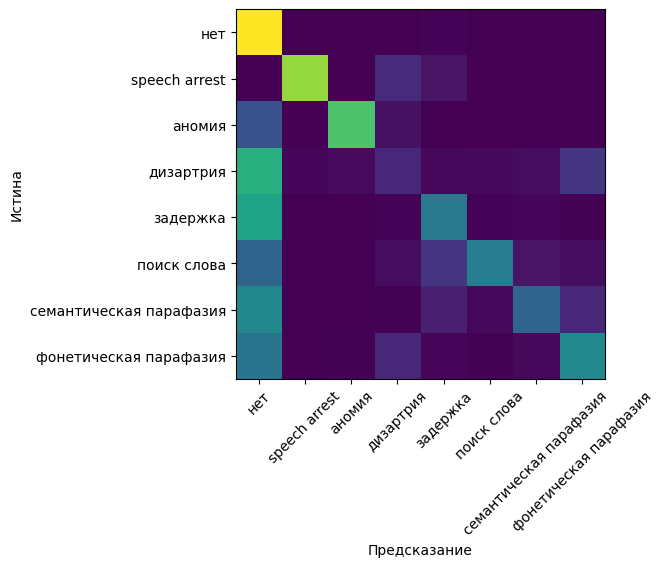

In [7]:
evaluate(DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED))


# Простые решения

5it [00:32,  6.58s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.96±0.00	0.95±0.00
speech arrest           0.88±0.10	0.80±0.18	0.83±0.12
аномия                  0.76±0.07	0.69±0.11	0.72±0.08
дизартрия               0.26±0.06	0.18±0.05	0.21±0.05
задержка                0.45±0.02	0.40±0.01	0.42±0.02
поиск слова             0.51±0.11	0.53±0.11	0.52±0.10
семантическая парафазия 0.71±0.05	0.38±0.09	0.49±0.08
фонетическая парафазия  0.53±0.07	0.47±0.07	0.49±0.06
По всем                 0.63±0.01	0.55±0.02	0.58±0.02


np.float64(0.5779264596300571)

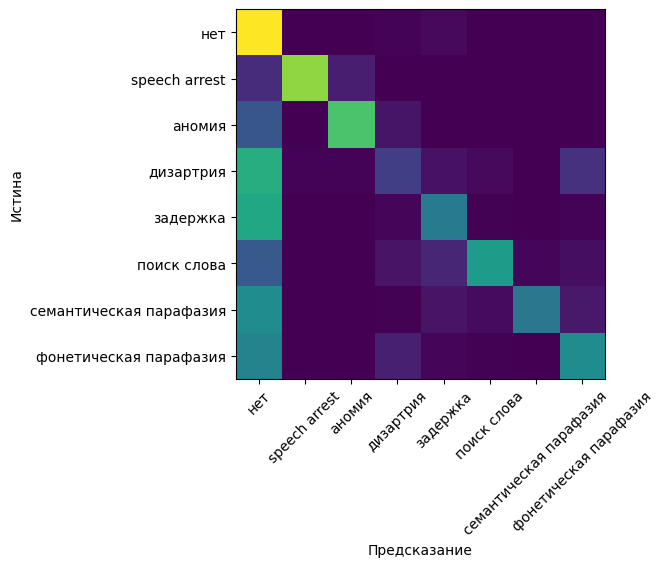

In [10]:
evaluate(RandomForestClassifier(random_state=SEED))


Лучше находит семантическую парафазию, в остальном всё так же

0it [00:00, ?it/s]

5it [01:49, 21.81s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.97±0.00
speech arrest           0.93±0.09	0.76±0.23	0.81±0.15
аномия                  0.72±0.10	0.68±0.13	0.69±0.10
дизартрия               0.51±0.10	0.13±0.04	0.21±0.06
задержка                0.70±0.04	0.44±0.01	0.54±0.02
поиск слова             0.63±0.15	0.56±0.05	0.59±0.09
семантическая парафазия 0.68±0.05	0.37±0.10	0.48±0.10
фонетическая парафазия  0.61±0.07	0.46±0.06	0.52±0.05
По всем                 0.72±0.02	0.55±0.02	0.60±0.04


np.float64(0.6000398591699158)

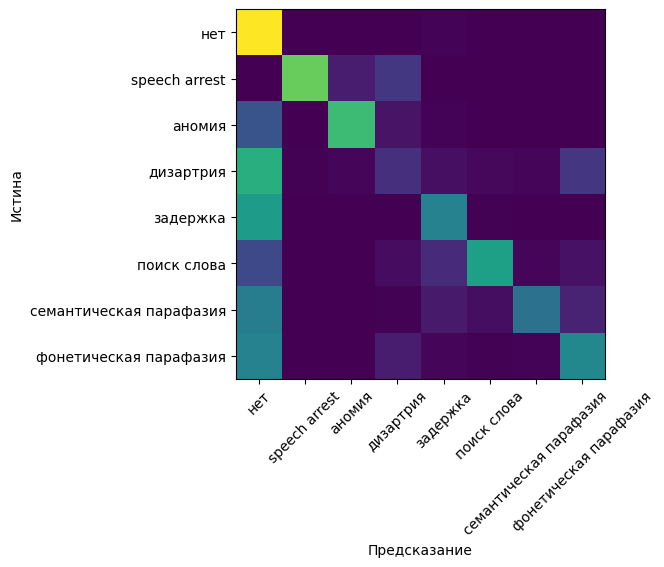

In [11]:
evaluate(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))


Немного лучше RF.

# Полезность групп признаков для отдельных классов

In [91]:
folds_train[0][0].columns

['RT_start',
 'relative_length',
 'delete_normalized_total',
 'insert_normalized_total',
 'replace_normalized_total',
 'word_list_distance_0',
 'word_list_distance_1',
 'word_list_distance_2',
 'word_list_frequency_difference_0',
 'word_list_frequency_difference_1',
 'word_list_frequency_difference_2',
 'ruwordnet_graph_distance_0',
 'ruwordnet_graph_distance_1',
 'ruwordnet_graph_distance_2',
 'ruwordnet_n_paths_0',
 'ruwordnet_n_paths_1',
 'ruwordnet_n_paths_2',
 'ruwordnet_levenshtein_distance_0',
 'ruwordnet_levenshtein_distance_1',
 'ruwordnet_levenshtein_distance_2',
 'ruwordnet_graph_distance_min',
 'insert_э',
 'insert_ ',
 'insert_т',
 'insert_о',
 'delete_ь',
 'insert_е',
 'delete_а',
 'replace_а_е',
 'delete_и',
 'replace_р_т',
 'insert_а',
 'insert_у',
 'replace_а_и',
 'delete_о',
 'replace_и_е',
 'insert_п',
 'insert_к',
 'replace_к_т',
 'insert_и',
 'replace_е_и',
 'delete_с',
 'replace_к_н',
 'insert_ь',
 'delete_т',
 'delete_в',
 'insert_л',
 'replace_о_у',
 'replace_е_

In [32]:
column_group_names = ['RT_start', 'relative_length',
                      '^.+_normalized_total$', '^word_list_.+$',
                      '^ruwordnet_.+$', '^.+_[а-яё ]$']


In [38]:
def get_powerset(items):
    items = list(items)
    return chain.from_iterable(combinations(items, r)
                               for r in range(len(items) + 1))


In [ ]:
column_groups_used = []
f1s_for_column_groups = np.zeros((64, 8))
for j, column_groups in enumerate(get_powerset(column_group_names)):
    column_groups_used.append(column_groups)
    f1s_for_column_groups[j] = evaluate(
                                DecisionTreeClassifier(max_depth=10,
                                                    random_state=SEED),
                                output_separate_f1s=True,
                                include_features=list(column_groups),
                                supress_print=True,
                                supress_plot=True)
    

5it [00:03,  1.38it/s]
0it [00:00, ?it/s]c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of

In [135]:
f1s_for_column_groups.argmax(axis=0)

array([51, 46, 54, 54, 11, 49, 33, 60])

In [136]:
f1s_for_column_groups.max(axis=0)

array([0.96382323, 0.85050505, 0.73644356, 0.24751058, 0.51323863,
       0.5539798 , 0.47227085, 0.5249084 ])

In [142]:
f1s_for_column_groups.max(axis=0).mean()

np.float64(0.6078350116575919)

In [138]:
f1s_for_column_groups[f1s_for_column_groups.argmax(axis=0)].round(2)

array([[0.96, 0.39, 0.65, 0.12, 0.5 , 0.42, 0.29, 0.52],
       [0.96, 0.85, 0.72, 0.1 , 0.5 , 0.46, 0.22, 0.16],
       [0.96, 0.82, 0.74, 0.25, 0.2 , 0.42, 0.4 , 0.47],
       [0.96, 0.82, 0.74, 0.25, 0.2 , 0.42, 0.4 , 0.47],
       [0.96, 0.52, 0.54, 0.05, 0.51, 0.52, 0.2 , 0.11],
       [0.96, 0.82, 0.72, 0.12, 0.5 , 0.55, 0.26, 0.46],
       [0.96, 0.53, 0.66, 0.22, 0.12, 0.36, 0.47, 0.48],
       [0.96, 0.72, 0.7 , 0.1 , 0.5 , 0.44, 0.32, 0.52]])

In [35]:
column_groups_used

NameError: name 'column_groups_used' is not defined

In [141]:
np.array(column_groups_used, dtype=object)\
    [f1s_for_column_groups.argmax(axis=0)]

array([('RT_start', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$'),
       ('RT_start', 'relative_length', '^word_list_.+$', '^.+_[а-яё ]$'),
       ('relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$'),
       ('relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$'),
       ('RT_start', '^.+_[а-яё ]$'),
       ('RT_start', '^.+_normalized_total$', '^word_list_.+$', '^.+_[а-яё ]$'),
       ('relative_length', '^.+_normalized_total$', '^ruwordnet_.+$'),
       ('RT_start', 'relative_length', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
      dtype=object)

# Ансамблирование

Посмотрим, какие классы (группы классов) простое decision tree лучше всего может разделить. Также посмотрим, какие признаки оно для этого использует

In [63]:
combinations_some_v_rest = [list(i)
                for i in itertools.product([0, 1], repeat=8)][1:130]


In [ ]:
macro_f1s_SvR: list[float] = []
trees_SvR: list[DecisionTreeClassifier] = []

for combination in combinations_some_v_rest:
    tree = DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED)
    macro_f1s_SvR.append(evaluate(tree,
                              merge_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_SvR.append(tree)


In [ ]:
joblib.dump((macro_f1s_SvR, trees_SvR),
            'class_subsets_bruteforce.joblib.xz', 9)


['class_subsets_bruteforce.joblib.xz']

In [ ]:
macro_f1s_SvR, trees_SvR =\
      joblib.load('class_subsets_bruteforce.joblib.xz')


In [42]:
np.set_printoptions(linewidth=72, threshold=float('+inf'))

In [ ]:
np.array(macro_f1s_SvR)[np.argsort(-np.array(macro_f1s_SvR))]

array([0.93625788, 0.85062887, 0.84589687, 0.82610514, 0.81109957,
       0.8012556 , 0.79404021, 0.78948184, 0.7877796 , 0.787429  ,
       0.7868984 , 0.78680389, 0.78648162, 0.78549387, 0.78523864,
       0.78296132, 0.78242983, 0.78190612, 0.78082703, 0.77748179,
       0.77672325, 0.7758751 , 0.77490262, 0.77438203, 0.77390942,
       0.77350677, 0.77070169, 0.76921292, 0.76918227, 0.76880662,
       0.76781659, 0.76767897, 0.76679525, 0.76621074, 0.76587118,
       0.76516964, 0.76448826, 0.76349629, 0.76312057, 0.76271955,
       0.76241922, 0.76181787, 0.76092681, 0.76071191, 0.75986093,
       0.75941493, 0.75927964, 0.75927195, 0.75924654, 0.75747348,
       0.7568501 , 0.75592437, 0.75584101, 0.75576378, 0.75554388,
       0.75541797, 0.75511062, 0.75485378, 0.75471594, 0.7528799 ,
       0.75273289, 0.75187627, 0.75168825, 0.7516132 , 0.75081216,
       0.75072501, 0.74982108, 0.74897129, 0.74770387, 0.74714901,
       0.74697538, 0.74691897, 0.74618344, 0.74603939, 0.74577

In [ ]:
np.array(combinations_some_v_rest)[np.argsort(-np.array(macro_f1s_SvR))]


array([[0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 1, 1, 0, 0, 0, 1, 0],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 1],
       [0, 1, 0, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 1],
       [0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 0, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 0],
       [0, 0, 1, 1, 0, 1, 0, 1],
       [0, 1, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [0, 1, 1, 1, 0, 0, 0, 1],
       [0, 1, 1, 1, 1, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0,

Посмотрим, какие перспективы есть для 1 vs all

In [ ]:
np.array(combinations_some_v_rest)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1]

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
np.argsort(-np.array(macro_f1s_SvR)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1])


array([1, 2, 0, 5, 4, 7, 6, 3])

In [ ]:
np.sort(np.array(macro_f1s_SvR)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1])[::-1]

array([0.93625788, 0.84589687, 0.7868984 , 0.7528799 , 0.7272812 ,
       0.71345458, 0.65829164, 0.56885555])

И для one vs one.

In [76]:
combinations_one_v_one = [set(i)
                for i in itertools.combinations([0,1,2,3,4,5,6,7], 2)]

In [77]:
macro_f1s_1v1: list[float] = []
trees_1v1: list[DecisionTreeClassifier] = []

for combination in combinations_one_v_one:
    tree = DecisionTreeClassifier(max_depth=3, # обосновать в тексте
                                random_state=SEED)
    macro_f1s_1v1.append(evaluate(tree,
                              include_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_1v1.append(tree)


5it [00:01,  2.88it/s]
5it [00:01,  3.58it/s]
5it [00:01,  3.52it/s]
5it [00:01,  3.59it/s]
5it [00:01,  3.65it/s]
5it [00:01,  3.17it/s]
5it [00:01,  3.89it/s]
5it [00:00, 53.19it/s]
5it [00:00, 49.02it/s]
5it [00:00, 42.37it/s]
5it [00:00, 59.53it/s]
5it [00:00, 50.00it/s]
5it [00:00, 51.55it/s]
5it [00:00, 47.17it/s]
5it [00:00, 34.72it/s]
5it [00:00, 54.94it/s]
5it [00:00, 47.62it/s]
5it [00:00, 44.64it/s]
5it [00:00, 31.65it/s]
5it [00:00, 45.45it/s]
5it [00:00, 43.86it/s]
5it [00:00, 43.48it/s]
5it [00:00, 36.50it/s]
5it [00:00, 32.89it/s]
5it [00:00, 32.68it/s]
5it [00:00, 52.08it/s]
5it [00:00, 47.62it/s]
5it [00:00, 40.32it/s]


In [78]:
np.array(macro_f1s_1v1)[np.argsort(-np.array(macro_f1s_1v1))]

array([1.        , 1.        , 1.        , 1.        , 0.97604534,
       0.95519446, 0.95299037, 0.93137176, 0.9304713 , 0.92355684,
       0.91595902, 0.90379938, 0.89333695, 0.87410126, 0.86895984,
       0.86531207, 0.84531086, 0.83570615, 0.83371089, 0.83294184,
       0.8311701 , 0.81523525, 0.76978738, 0.63198842, 0.61699126,
       0.61354015, 0.60760504, 0.54891868])

In [79]:
np.array(combinations_one_v_one)[np.argsort(-np.array(macro_f1s_1v1))]


array([{1, 2}, {1, 7}, {1, 5}, {1, 6}, {1, 4}, {2, 7}, {2, 4}, {2, 5},
       {0, 1}, {2, 6}, {0, 2}, {2, 3}, {1, 3}, {5, 7}, {4, 7}, {6, 7},
       {3, 6}, {5, 6}, {3, 4}, {3, 5}, {4, 5}, {0, 5}, {4, 6}, {0, 7},
       {0, 4}, {3, 7}, {0, 6}, {0, 3}], dtype=object)

У обоих способов получаются результаты лучше чем у просто дерева. С 1v1 есть проблема с неизвестными базовой модели классами, поэтому попробуем 1vR.

In [57]:
base_model = DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED)
ovr_classifier = OneVsRestClassifier(base_model)


Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
speech arrest           0.85±0.15	0.88±0.16	0.86±0.15
аномия                  0.66±0.08	0.70±0.08	0.68±0.07
дизартрия               0.32±0.04	0.18±0.03	0.23±0.04
задержка                0.60±0.05	0.41±0.02	0.49±0.02
поиск слова             0.52±0.09	0.39±0.09	0.44±0.09
семантическая парафазия 0.42±0.08	0.42±0.07	0.42±0.07
фонетическая парафазия  0.61±0.09	0.34±0.05	0.43±0.05
По всем                 0.62±0.02	0.54±0.02	0.56±0.02


np.float64(0.5640912749993137)

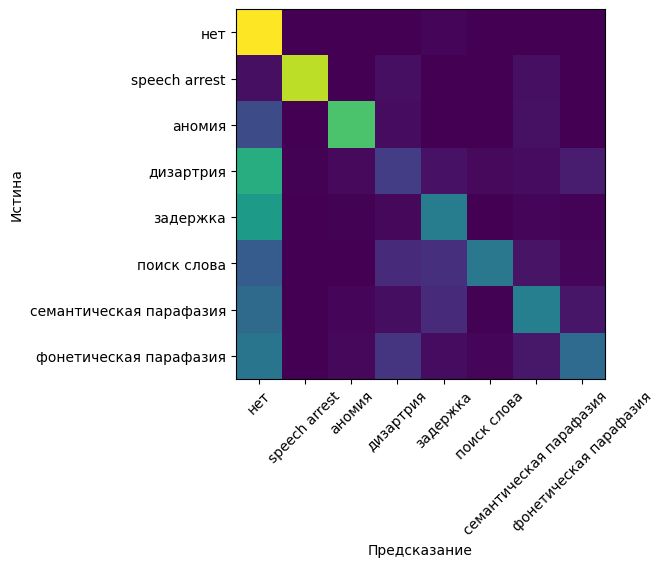

In [34]:
evaluate(ovr_classifier)


## 1 vs 1 с нейтральным классом

In [17]:
combinations_1v1vN_ = set(itertools.permutations([1,1,0,0,0,0,0,0]))

In [18]:
combinations_1v1vN = set()
for combination in combinations_1v1vN_:
    combination = list(combination)
    combination[combination.index(1)] = -1
    combinations_1v1vN.add(tuple(combination))


In [152]:
macro_f1s_1v1vN: list[float] = []
trees_1v1vN: list[DecisionTreeClassifier] = []

for combination in tqdm(combinations_1v1vN):
    tree = DecisionTreeClassifier(max_depth=10, 
                                random_state=SEED)
    macro_f1s_1v1vN.append(evaluate(tree,
                              merge_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_1v1vN.append(tree)


5it [00:05,  1.14s/it][00:00<?, ?it/s]
5it [00:04,  1.23it/s][00:05<02:34,  5.71s/it]
5it [00:03,  1.36it/s][00:09<02:03,  4.74s/it]
5it [00:02,  2.22it/s][00:13<01:46,  4.26s/it]
5it [00:01,  2.58it/s][00:15<01:23,  3.47s/it]
5it [00:04,  1.12it/s][00:17<01:07,  2.92s/it]
5it [00:04,  1.09it/s][00:22<01:15,  3.45s/it]
5it [00:02,  1.84it/s][00:26<01:20,  3.82s/it]
5it [00:03,  1.42it/s][00:29<01:09,  3.47s/it]
5it [00:03,  1.62it/s][00:32<01:06,  3.49s/it]
5it [00:04,  1.07it/s] [00:36<01:00,  3.37s/it]
5it [00:04,  1.19it/s] [00:40<01:04,  3.77s/it]
5it [00:02,  2.36it/s] [00:44<01:02,  3.91s/it]
5it [00:02,  2.29it/s] [00:47<00:50,  3.37s/it]
5it [00:02,  2.21it/s] [00:49<00:42,  3.01s/it]
5it [00:03,  1.46it/s] [00:51<00:36,  2.79s/it]
5it [00:02,  1.72it/s] [00:55<00:35,  2.98s/it]
5it [00:02,  2.05it/s] [00:57<00:32,  2.97s/it]
5it [00:02,  1.94it/s] [01:00<00:28,  2.81s/it]
5it [00:01,  2.71it/s] [01:02<00:24,  2.75s/it]
5it [00:02,  1.99it/s] [01:04<00:19,  2.48s/it]
5it [00:03

In [145]:
sorted(macro_f1s_1v1vN)

[np.float64(0.47021035102224096),
 np.float64(0.4714612533501022),
 np.float64(0.515487421926456),
 np.float64(0.5187565546898899),
 np.float64(0.53815969802911),
 np.float64(0.5394209727024085),
 np.float64(0.5396689681326423),
 np.float64(0.5433898859582265),
 np.float64(0.582716795620719),
 np.float64(0.5853764643961676),
 np.float64(0.5866238598422073),
 np.float64(0.5869428550709468),
 np.float64(0.5875969177709559),
 np.float64(0.5886951547344109),
 np.float64(0.5954299237630278),
 np.float64(0.6031650121440603),
 np.float64(0.6058728283972625),
 np.float64(0.6062907862543793),
 np.float64(0.6168485445245968),
 np.float64(0.6177909736442511),
 np.float64(0.6194172935120872),
 np.float64(0.61944408502196),
 np.float64(0.63176033037464),
 np.float64(0.6348992136946114),
 np.float64(0.6368705067688667),
 np.float64(0.6368705067688667),
 np.float64(0.6419889381033005),
 np.float64(0.6420624828089025),
 np.float64(0.6439282402581427),
 np.float64(0.6536023650803652),
 np.float64(0.660

## Подбор признаков для каждого 1v1vN

In [36]:
column_groups_to_use: list[tuple[str,...]] = list(
                                    get_powerset(column_group_names))

In [ ]:
f1s_for_column_groups_1v1vn = np.zeros((28, 64, 3))
for i, combination in tqdm(enumerate(combinations_1v1vN)):
    # print(i, combination)
    for j, column_groups in enumerate(column_groups_to_use):
        # print(j, column_groups)
        f1s_for_column_groups_1v1vn[i, j] = evaluate(
                                DecisionTreeClassifier(max_depth=10,
                                                    random_state=SEED),
                                output_separate_f1s=True,
                                include_features=list(column_groups),
                                merge_classes=list(combination),
                                supress_print=True,
                                supress_plot=True)
        print(*f1s_for_column_groups_1v1vn[i, j].round(2))
    print(*f1s_for_column_groups_1v1vn.max(axis=(0,1)), '====')


In [205]:
joblib.dump(f1s_for_column_groups_1v1vn, '1v1vN_11.joblib.xz', 9)

['1v1vN_11.joblib.xz']

In [9]:
f1s_for_column_groups_1v1vn = joblib.load('1v1vN_11.joblib.xz')

In [11]:
f1s_for_column_groups_1v1vn_macro = f1s_for_column_groups_1v1vn\
                                             .mean(axis=2)

In [14]:
np.sort(f1s_for_column_groups_1v1vn_macro.max(axis=1))

array([0.54610927, 0.54906252, 0.55178676, 0.56446482, 0.59784797,
       0.59897147, 0.62578916, 0.62786887, 0.63925467, 0.6445736 ,
       0.6525086 , 0.65954095, 0.66086674, 0.67280884, 0.6789357 ,
       0.68191621, 0.70134958, 0.73052979, 0.73153996, 0.73515628,
       0.73883862, 0.74643679, 0.7664226 , 0.77828634, 0.78575165,
       0.79269858, 0.79623056, 0.87896553])

Неплохо. Посмотрим, с какими парами классов модели всё ещё плохо справлются.

In [29]:
np.array(list(combinations_1v1vN))[
np.argsort(f1s_for_column_groups_1v1vn_macro.max(axis=1))]\
    .nonzero()[1]\
    .reshape(-1, 2)

array([[3, 6],
       [3, 5],
       [3, 4],
       [3, 7],
       [0, 3],
       [4, 6],
       [2, 3],
       [0, 6],
       [5, 6],
       [6, 7],
       [1, 3],
       [4, 7],
       [0, 7],
       [4, 5],
       [0, 5],
       [5, 7],
       [0, 4],
       [2, 4],
       [2, 7],
       [2, 6],
       [1, 6],
       [2, 5],
       [0, 2],
       [1, 4],
       [0, 1],
       [1, 7],
       [1, 5],
       [1, 2]])

Плохо с дизартрией, как обычно. Хорошо простыми классами, как задержка и аномия.

Посмотрим лучшие наборы признаков для пар классов

In [57]:
np.set_printoptions(linewidth=np.inf)

In [ ]:
class_pairs_and_features_all = np.hstack(
[
        np.array(list(combinations_1v1vN))\
            .nonzero()[1]\
            .reshape(-1, 2),
            
            np.array(column_groups_to_use, dtype=object)[:, np.newaxis]\
    [f1s_for_column_groups_1v1vn_macro.argmax(axis=1)],]
    )

In [ ]:
class_pairs_and_features_all

array([[1, 3, ('RT_start', '^.+_normalized_total$', '^word_list_.+$', '^.+_[а-яё ]$')],
       [2, 3, ('^.+_normalized_total$', '^word_list_.+$', '^ruwordnet_.+$')],
       [4, 5, ('RT_start', 'relative_length', '^.+_[а-яё ]$')],
       [0, 3, ('RT_start', '^.+_normalized_total$', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [0, 1, ()],
       [2, 5, ('RT_start', 'relative_length', '^.+_normalized_total$', '^.+_[а-яё ]$')],
       [1, 2, ('relative_length', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [4, 6, ('RT_start', 'relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [3, 6, ('^.+_normalized_total$', '^ruwordnet_.+$')],
       [1, 6, ('relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [1, 5, ('RT_start', 'relative_length', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [3, 5, ('relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [0, 7, ()],
       [0,

(Пустые таплы — весь набор фич)

Нужно построить estimator, который строит 28 деверьев с соответствующими признаками и упрощёнными метками классов.

In [ ]:
class_pairs_and_features_all = class_pairs_and_features_all[
    np.lexsort((class_pairs_and_features_all[:, 1],
                class_pairs_and_features_all[:, 0]))
]

In [ ]:
class_pairs_and_features_ = pl.DataFrame(class_pairs_and_features_all[:,0:2].astype(np.int8)).hstack(
    pl.DataFrame(class_pairs_and_features_all[:,2],
                 schema=['include_features'])
).with_columns(
    pl.col('include_features')\
        .map_elements(lambda x: str('\uE000'.join(x)),
                      return_dtype=pl.String)
).rename({'column_0': 'class_1', 'column_1': 'class_2'})


In [122]:
class_pairs_and_features_

class_1,class_2,include_features
i8,i8,str
0,1,""""""
0,2,"""RT_start^.+_normalized_total$…"
0,3,"""RT_start^.+_normalized_total$…"
0,4,"""RT_start^.+_normalized_total$…"
0,5,"""RT_startrelative_length^.+_n…"
…,…,…
4,6,"""RT_startrelative_length^.+_n…"
4,7,"""RT_start^.+_normalized_total$…"
5,6,"""RT_start^.+_normalized_total$…"


In [123]:
class_pairs_and_features_.write_csv('../data/models/'
                                    'class_pairs_and_features.csv')


In [8]:
class OneVsOneVsNeutralClassifier(BaseEstimator):
    def __init__(self,
                 base_model: BaseEstimator,
                 meta_model: BaseEstimator,
                 column_names: Sequence[str] | None = None,
                 class_pairs_and_features_path = '../data/models/'
                                    'class_pairs_and_features.csv'):
        self.column_names = column_names or []
        self.class_pairs_and_features_all = \
                            pl.read_csv(class_pairs_and_features_path)
        self.estimators: list[BaseEstimator] = []
        self.base_model = base_model
        self.meta_model = meta_model

    def _get_base_predictions(self, X):
        predictions = np.ndarray((len(X), len(self.estimators)))
        for i, model in enumerate(self.estimators):
            # смелое предположение; но у DecisionTreeClassifier есть
            X_this = X.select(model.feature_names_in_)
            predictions[:, i] = model.predict(X_this)
        return predictions

    def fit(self, X: pl.DataFrame | np.ndarray,
                  y: pl.Series | np.ndarray = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)
        if type(y) != pl.Series:
            y = pl.Series(y)
        self.classes_present = y.unique()
        self.class_pairs_and_features = \
                self.class_pairs_and_features_all.filter(
                pl.col('class_1').is_in(self.classes_present.implode())
                &pl.col('class_2').is_in(self.classes_present.implode())
                )\
                .with_columns(pl.col('include_features')\
                    .map_elements(lambda x: tuple(x.split('\uE000')),
                                    return_dtype=pl.Object))
        
        self.estimators = [] # у меня есть подозрения
        for specil in self.class_pairs_and_features.iter_rows():
            class_1, class_2, include_features = specil
            y_this = y.replace_strict({class_1: 1, class_2: -1},
                                        default=0)
            self.estimators.append(clone(self.base_model))
            X_this = X.select(pl.col(*include_features))\
                     if include_features[0] else X
            self.estimators[-1].fit(X_this, y_this)
        
        self.meta_model = clone(self.meta_model)
        self.meta_model.fit(self._get_base_predictions(X), y)
        return self

    def predict(self, X):
        return self.meta_model.predict(self._get_base_predictions(X))


In [11]:
ovovn_classifier = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=11, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
)


5it [01:24, 16.91s/it]

Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
speech arrest           0.92±0.10	0.76±0.29	0.79±0.24
аномия                  0.75±0.04	0.66±0.12	0.70±0.08
дизартрия               0.27±0.05	0.17±0.07	0.21±0.06
задержка                0.59±0.02	0.43±0.02	0.49±0.02
поиск слова             0.55±0.15	0.36±0.11	0.43±0.12
семантическая парафазия 0.46±0.13	0.42±0.12	0.44±0.12
фонетическая парафазия  0.51±0.04	0.39±0.08	0.44±0.06
По всем                 0.62±0.01	0.52±0.03	0.56±0.03


np.float64(0.5559508137326395)

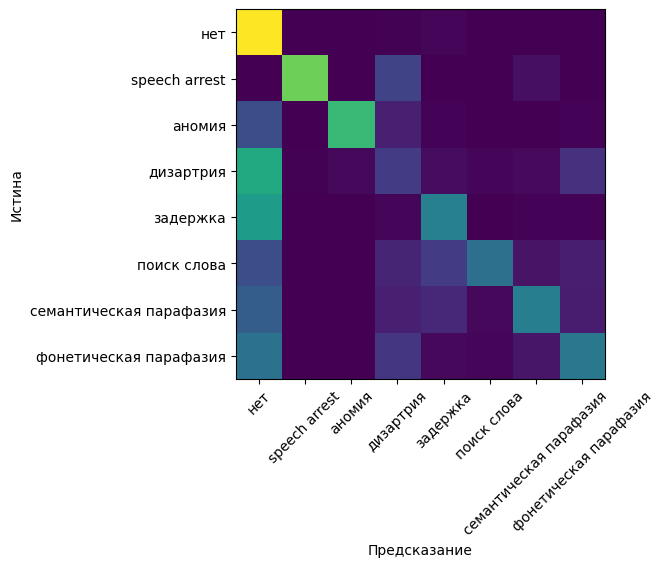

In [12]:
evaluate(ovovn_classifier)


In [13]:
for max_depth in range(1, 14):
    ovovn_classifier = OneVsOneVsNeutralClassifier(
        DecisionTreeClassifier(max_depth=max_depth,
                               random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
    )
    print(max_depth, evaluate(ovovn_classifier,
                              supress_print=True,
                              supress_plot=True))


1 0.2568318501695327
2 0.36457509941422295
3 0.5115954054951928
4 0.556294001769618
5 0.5872021707674443
6 0.6013349536350848
7 0.5668395859640691
8 0.5752313592802963
9 0.578125694541747
10 0.5619728687118204
11 0.5559508137326395
12 0.547137709160264
13 0.5463240871030652


5it [01:18, 15.74s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.97±0.00
speech arrest           0.86±0.13	0.92±0.10	0.89±0.11
аномия                  0.74±0.12	0.68±0.12	0.71±0.12
дизартрия               0.47±0.11	0.19±0.06	0.27±0.07
задержка                0.71±0.04	0.42±0.04	0.53±0.04
поиск слова             0.67±0.11	0.51±0.07	0.57±0.05
семантическая парафазия 0.47±0.12	0.34±0.13	0.39±0.12
фонетическая парафазия  0.65±0.06	0.41±0.10	0.49±0.08
По всем                 0.69±0.02	0.56±0.00	0.60±0.03


np.float64(0.6013349536350848)

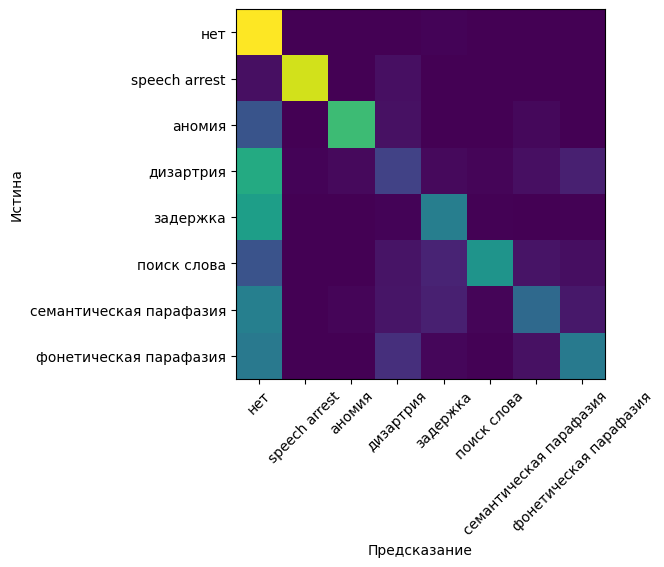

In [14]:
ovovn_classifier = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=6, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
)
evaluate(ovovn_classifier)


In [198]:
ovovn_classifier.meta_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# Всё то же самое, но уже с транскрипцией

In [24]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    ).drop('StimSite', 'Error_type_annot')\
    .filter(pl.col('Response_transcription_annot').str.len_chars() > 0)


In [25]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor()

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train: list[tuple[pl.DataFrame, pl.Series]] = []
folds_val: list[tuple[pl.DataFrame, pl.Series]] = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))
    assert (folds_train[-1][0].sum_horizontal().sum() * 0) == 0
    assert (folds_train[-1][0].null_count().sum_horizontal().sum()) == 0


1029it [00:11, 87.81it/s] 
382it [00:03, 103.75it/s]
1032it [00:09, 106.01it/s]
414it [00:03, 104.55it/s]
1040it [00:10, 99.65it/s]
406it [00:05, 80.43it/s]
1052it [00:11, 90.56it/s]
362it [00:03, 98.42it/s] 
1024it [00:09, 103.41it/s]
384it [00:03, 106.87it/s]


In [27]:
folds_train[0][0].sample(10)

RT_start,relative_length,relative_length_transcription,Tdelete_normalized_total,Tinsert_normalized_total,Treplace_normalized_total,delete_normalized_total,insert_normalized_total,replace_normalized_total,word_list_distance_0,word_list_distance_1,word_list_distance_2,word_list_frequency_difference_0,word_list_frequency_difference_1,word_list_frequency_difference_2,ruwordnet_graph_distance_0,ruwordnet_graph_distance_1,ruwordnet_graph_distance_2,ruwordnet_n_paths_0,ruwordnet_n_paths_1,ruwordnet_n_paths_2,ruwordnet_levenshtein_distance_0,ruwordnet_levenshtein_distance_1,ruwordnet_levenshtein_distance_2,ruwordnet_graph_distance_min,Tinsert_,Tinsert_т,Tinsert_',Tinsert_ъ,insert_,insert_э,insert_т,insert_о,Tinsert_э,Tinsert_у,Tinsert_/,Tinsert_а,…,replace_т_щ,replace_у_г,replace_у_й,replace_у_н,replace_у_ц,replace_у_ы,replace_ф_п,replace_ф_ц,replace_ф_ш,replace_х_г,replace_ц_р,replace_ч_,replace_ч_н,replace_ч_о,replace_ч_р,replace_ч_щ,replace_ч_ь,replace_ч_э,replace_ш_е,replace_ш_о,replace_ш_с,replace_ш_ч,replace_ш_щ,replace_ы_а,replace_ы_о,replace_ь_,replace_ь_е,replace_ь_т,replace_ь_ы,replace_ю_а,replace_ю_ж,replace_ю_у,replace_я_,replace_я_л,replace_я_р,replace_я_т,replace_я_ь
f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
743.0,1.125,1.25,0.0,0.25,1.0,0.0,0.125,1.0,3,5,5,7.683696,6.305185,4.683696,1,1,1,1,1,1,0.375,0.75,0.75,1,0,1,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1238.0,0.6,2.3,0.2,1.5,0.1,0.4,0.0,0.4,5,5,6,9.752381,0.584963,0.0,1,1,2,2,2,4,0.4,0.5,0.5,1,2,3,3,0,0,0,0,0,0,2,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
896.0,1.5,1.5,0.0,0.5,0.666667,0.0,0.5,0.666667,3,3,3,9.463232,10.270587,10.685625,1,0,1,2,1,1,0.5,0.833333,0.833333,0,0,1,0,0,0,1,1,0,1,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1287.0,0.875,3.0,0.125,2.125,0.25,0.125,0.0,0.0,2,4,4,6.375039,2.169925,1.584963,0,1,2,1,2,4,0.125,0.375,0.625,0,2,2,4,0,0,0,0,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1304.0,1.571429,1.857143,0.0,0.857143,0.285714,0.0,0.571429,0.0,3,3,3,0.0,9.606405,9.606405,0,1,1,1,2,2,0.0,0.714286,0.714286,0,1,1,1,1,1,1,1,1,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1548.0,1.0,2.375,0.125,1.5,0.125,0.125,0.125,0.0,1,1,3,4.087463,12.222191,0.0,0,1,1,1,2,3,0.25,0.5,0.75,0,2,3,1,0,0,0,0,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
901.0,1.428571,3.142857,0.142857,2.285714,0.0,0.142857,0.571429,0.0,2,2,3,2.169925,9.292322,4.169925,0,2,1,1,6,3,0.571429,1.0,1.142857,0,3,3,2,1,1,0,1,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
661.0,1.25,1.625,0.0,0.625,0.75,0.0,0.25,0.625,3,4,4,0.275513,8.292322,6.484967,1,0,1,2,1,2,0.0,0.625,0.75,0,1,1,1,0,0,1,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
823.0,2.0,2.25,0.0,1.25,0.5,0.0,1.0,0.0,4,4,4,0.0,11.083147,6.176256,0,1,1,1,1,1,0.0,1.0,1.25,0,1,1,0,1,1,1,1,1,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
def evaluate_T(model,
               folds_train = folds_train,
               folds_val = folds_val,
               *args, **kwargs):
    return evaluate(model, folds_train, folds_val, *args, **kwargs)


## Бейзлайн

In [31]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13+1):
    score = evaluate_T(DecisionTreeClassifier(max_depth=max_depth, 
                                                random_state=SEED),
                                                supress_plot=True,
                                                supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


5it [00:00, 16.45it/s]
5it [00:00, 14.53it/s]
5it [00:00, 10.57it/s]
5it [00:00, 13.23it/s]
5it [00:00, 11.57it/s]
5it [00:00, 12.50it/s]
5it [00:00,  8.94it/s]
5it [00:00, 13.74it/s]
5it [00:00, 13.74it/s]
5it [00:00, 12.44it/s]
5it [00:00, 12.59it/s]
5it [00:00, 11.52it/s]
5it [00:00, 12.17it/s]


In [32]:
best_max_depth

12

5it [00:00,  7.60it/s]

Класс			Precision	Recall		F1
нет                     0.17±0.07	0.16±0.08	0.16±0.07
аномия                  0.82±0.11	0.77±0.09	0.79±0.08
дизартрия               0.48±0.05	0.44±0.04	0.46±0.01
задержка                0.80±0.02	0.82±0.03	0.81±0.02
поиск слова             0.54±0.12	0.46±0.15	0.48±0.11
семантическая парафазия 0.42±0.14	0.42±0.19	0.42±0.16
фонетическая парафазия  0.59±0.02	0.63±0.05	0.60±0.02
По всем                 0.55±0.02	0.53±0.04	0.53±0.04


np.float64(0.5319059685210672)

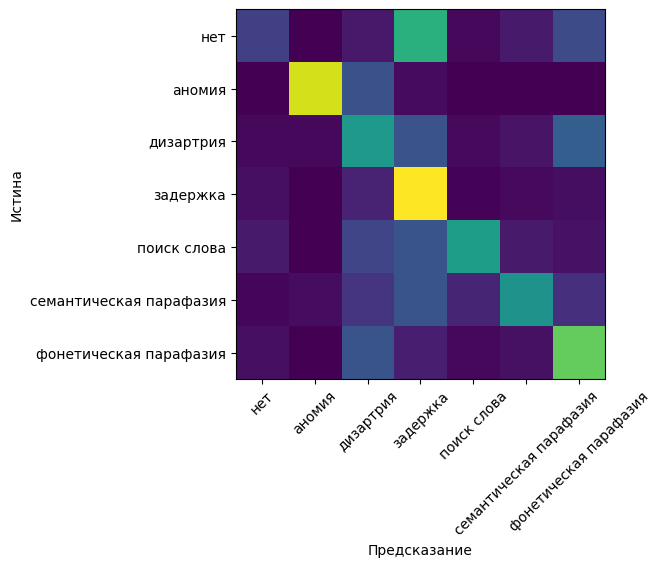

In [33]:
evaluate_T(DecisionTreeClassifier(max_depth=12, 
                                    random_state=SEED))

## Простые решения

5it [00:05,  1.08s/it]

Класс			Precision	Recall		F1
нет                     0.24±0.04	0.14±0.05	0.17±0.05
аномия                  0.88±0.10	0.82±0.13	0.84±0.07
дизартрия               0.58±0.08	0.45±0.07	0.51±0.07
задержка                0.76±0.02	0.93±0.02	0.83±0.02
поиск слова             0.69±0.09	0.50±0.14	0.57±0.11
семантическая парафазия 0.79±0.12	0.31±0.10	0.44±0.12
фонетическая парафазия  0.66±0.04	0.66±0.06	0.65±0.03
По всем                 0.66±0.02	0.54±0.02	0.57±0.03


np.float64(0.5730461871553787)

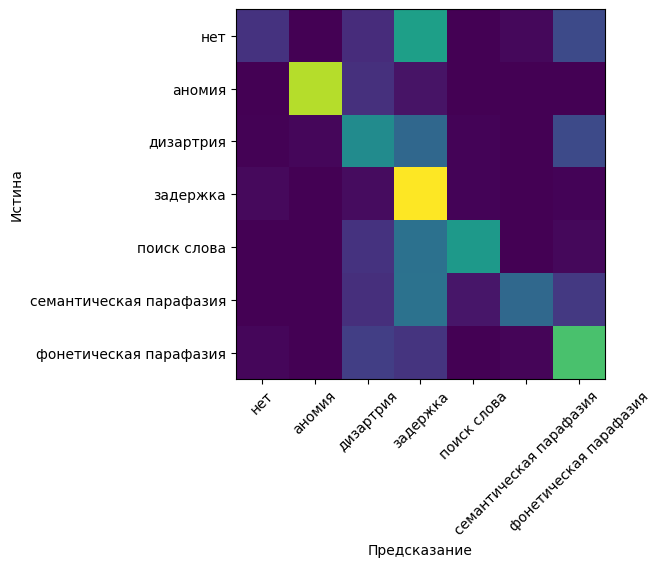

In [34]:
evaluate_T(RandomForestClassifier(random_state=SEED))


5it [02:17, 27.45s/it]

Класс			Precision	Recall		F1
нет                     0.03±0.07	0.02±0.04	0.03±0.05
аномия                  0.90±0.09	0.82±0.13	0.85±0.07
дизартрия               0.65±0.03	0.55±0.06	0.59±0.03
задержка                0.82±0.01	0.93±0.03	0.87±0.01
поиск слова             0.73±0.17	0.52±0.13	0.58±0.07
семантическая парафазия 0.62±0.15	0.48±0.13	0.53±0.11
фонетическая парафазия  0.69±0.03	0.76±0.04	0.72±0.02
По всем                 0.64±0.02	0.58±0.02	0.60±0.02


np.float64(0.5960871806451691)

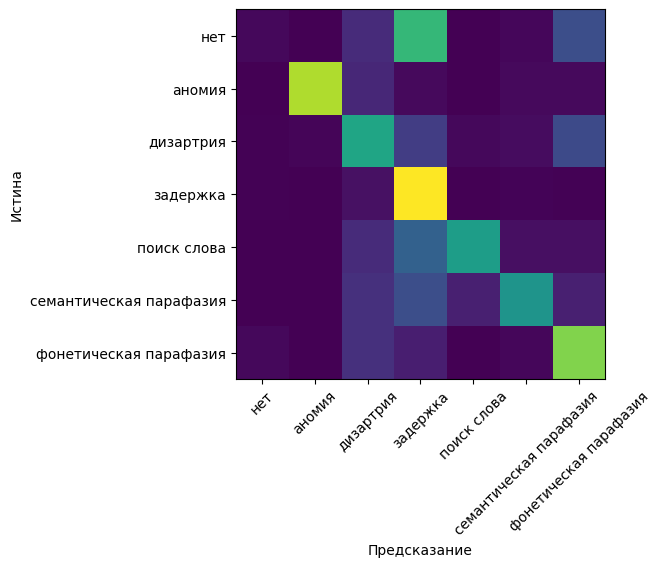

In [35]:
evaluate_T(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))

## Подбор признаков для каждого 1v1vN

In [36]:
column_group_names = ['RT_start',
                      'relative_length',
                      'relative_length_transcription',
                      '^[^T].+_normalized_total$',
                      '^T.+_normalized_total$',
                      '^word_list_.+$',
                      '^ruwordnet_.+$',
                      '^[^T].+_[а-яё ]$',
                      '^T.+_[а-яё ]$']


In [43]:
column_groups_to_use: list[tuple[str,...]] = list(
                                    get_powerset(column_group_names))

In [44]:
combinations_1v1vN_ = set(itertools.permutations([1,1,0,0,0,0,0]))

In [45]:
combinations_1v1vN = set()
for combination in combinations_1v1vN_:
    combination = list(combination)
    # обработка отсуствия speech arrest
    combination = combination[:1] + [0] + combination[1:]
    combination[combination.index(1)] = -1
    combinations_1v1vN.add(tuple(combination))

In [49]:
f1s_for_column_groups_1v1vn = np.zeros((28, 512, 3))
for i, combination in tqdm(enumerate(combinations_1v1vN)):
    # print(i, combination)
    for j, column_groups in tqdm(enumerate(column_groups_to_use)):
        # print(j, column_groups)
        f1s_for_column_groups_1v1vn[i, j] = evaluate_T(
                                DecisionTreeClassifier(max_depth=12,
                                                    random_state=SEED),
                                output_separate_f1s=True,
                                include_features=list(column_groups),
                                merge_classes=list(combination),
                                supress_print=True,
                                supress_plot=True)
        # print(*f1s_for_column_groups_1v1vn[i, j].round(2))
    print(*f1s_for_column_groups_1v1vn.max(axis=(0,1)), '====')


512it [02:12,  3.88it/s]
1it [02:12, 132.08s/it]

0.8741736694677871 0.8821816875150796 0.44897644353454896 ====


512it [02:15,  3.77it/s]
2it [04:27, 134.33s/it]

0.8741736694677871 0.8821816875150796 0.6066475279106858 ====


512it [02:10,  3.91it/s]
3it [06:38, 132.73s/it]

0.8741736694677871 0.8821816875150796 0.6066475279106858 ====


512it [02:39,  3.20it/s]
4it [09:18, 143.46s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [01:52,  4.56it/s]
5it [11:10, 132.20s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [02:00,  4.24it/s]
6it [13:11, 128.36s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [01:59,  4.29it/s]
7it [15:11, 125.42s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [02:05,  4.07it/s]
8it [17:17, 125.55s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [02:11,  3.88it/s]
9it [19:28, 127.52s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [01:59,  4.29it/s]
10it [21:28, 125.04s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:07,  4.03it/s]
11it [23:35, 125.68s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:10,  3.91it/s]
12it [25:46, 127.23s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:08,  3.98it/s]
13it [27:54, 127.65s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [01:56,  4.39it/s]
14it [29:51, 124.28s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [01:49,  4.68it/s]
15it [31:40, 119.77s/it]

0.8788888888888889 0.9819215974660505 0.8267290712621722 ====


512it [02:01,  4.22it/s]
16it [33:42, 120.26s/it]

0.8788888888888889 0.9819215974660505 0.8267290712621722 ====


512it [02:39,  3.21it/s]
17it [36:21, 132.01s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [02:00,  4.24it/s]
18it [38:22, 128.65s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [01:50,  4.62it/s]
19it [40:13, 123.28s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [01:46,  4.80it/s]
20it [41:59, 118.31s/it]

0.9080952380952381 0.9819215974660505 0.858421052631579 ====


512it [02:38,  3.22it/s]
21it [44:38, 127.56s/it]

0.9080952380952381 0.9819215974660505 0.858421052631579 ====


In [50]:
joblib.dump(f1s_for_column_groups_1v1vn, '1v1vNT_12.joblib.xz', 9)

['1v1vNT_12.joblib.xz']

In [55]:
f1s_for_column_groups_1v1vn_macro = f1s_for_column_groups_1v1vn\
                                             .mean(axis=2)[:21]

In [57]:
np.array(list(combinations_1v1vN))[
np.argsort(f1s_for_column_groups_1v1vn_macro.max(axis=1))]\
    .nonzero()[1]\
    .reshape(-1, 2)

array([[0, 3],
       [0, 5],
       [0, 6],
       [3, 6],
       [0, 7],
       [0, 4],
       [3, 5],
       [0, 2],
       [3, 4],
       [6, 7],
       [3, 7],
       [5, 7],
       [4, 6],
       [5, 6],
       [4, 7],
       [2, 3],
       [4, 5],
       [2, 6],
       [2, 7],
       [2, 5],
       [2, 4]])

In [58]:
np.set_printoptions(linewidth=np.inf)

In [59]:
class_pairs_and_features_all = np.hstack(
[
        np.array(list(combinations_1v1vN))\
            .nonzero()[1]\
            .reshape(-1, 2),
            
            np.array(column_groups_to_use, dtype=object)[:, np.newaxis]\
    [f1s_for_column_groups_1v1vn_macro.argmax(axis=1)],]
    )

In [60]:
class_pairs_and_features_all

array([[2, 3, ('RT_start', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$')],
       [4, 5, ()],
       [0, 3, ()],
       [2, 5, ('RT_start', 'relative_length_transcription', '^T.+_normalized_total$', '^word_list_.+$', '^[^T].+_[а-яё ]$')],
       [4, 6, ('relative_length', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 6, ('relative_length', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$')],
       [0, 7, ('RT_start', 'relative_length', '^[^T].+_normalized_total$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 5, ()],
       [0, 6, ('relative_length', 'relative_length_transcription', '^word_list_.+$', '^ruwordnet_.+$')],
       [2, 7, ('RT_start', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [2, 6, ('RT_start', 'relative_length',

In [61]:
class_pairs_and_features_all = class_pairs_and_features_all[
    np.lexsort((class_pairs_and_features_all[:, 1],
                class_pairs_and_features_all[:, 0]))
]

In [62]:
class_pairs_and_features_all

array([[0, 2, ()],
       [0, 3, ()],
       [0, 4, ()],
       [0, 5, ('RT_start', 'relative_length', 'relative_length_transcription', '^T.+_normalized_total$', '^[^T].+_[а-яё ]$')],
       [0, 6, ('relative_length', 'relative_length_transcription', '^word_list_.+$', '^ruwordnet_.+$')],
       [0, 7, ('RT_start', 'relative_length', '^[^T].+_normalized_total$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [2, 3, ('RT_start', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$')],
       [2, 4, ()],
       [2, 5, ('RT_start', 'relative_length_transcription', '^T.+_normalized_total$', '^word_list_.+$', '^[^T].+_[а-яё ]$')],
       [2, 6, ('RT_start', 'relative_length', 'relative_length_transcription', '^[^T].+_normalized_total$', '^word_list_.+$', '^T.+_[а-яё ]$')],
       [2, 7, ('RT_start', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 4, ()],
       [3, 5, 

In [63]:
class_pairs_and_features_ = pl.DataFrame(class_pairs_and_features_all[:,0:2].astype(np.int8)).hstack(
    pl.DataFrame(class_pairs_and_features_all[:,2],
                 schema=['include_features'])
).with_columns(
    pl.col('include_features')\
        .map_elements(lambda x: str('\uE000'.join(x)),
                      return_dtype=pl.String)
).rename({'column_0': 'class_1', 'column_1': 'class_2'})


In [64]:
class_pairs_and_features_

class_1,class_2,include_features
i8,i8,str
0,2,""""""
0,3,""""""
0,4,""""""
0,5,"""RT_startrelative_lengthrelat…"
0,6,"""relative_lengthrelative_lengt…"
…,…,…
4,6,"""relative_lengthrelative_lengt…"
4,7,""""""
5,6,""""""


In [65]:
class_pairs_and_features_.write_csv('../data/models/'
                                    'class_pairs_and_featuresT.csv')


## 1 vs 1 с нейтральным классом

In [76]:
ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=12, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
    )

5it [00:09,  1.84s/it]

Класс			Precision	Recall		F1
нет                     0.16±0.04	0.27±0.09	0.19±0.06
аномия                  0.83±0.14	0.72±0.12	0.77±0.12
дизартрия               0.53±0.05	0.61±0.08	0.56±0.02
задержка                0.85±0.03	0.80±0.02	0.83±0.02
поиск слова             0.75±0.07	0.53±0.24	0.59±0.19
семантическая парафазия 0.50±0.16	0.42±0.07	0.44±0.08
фонетическая парафазия  0.66±0.07	0.57±0.04	0.61±0.05
По всем                 0.61±0.04	0.56±0.05	0.57±0.05


np.float64(0.5697565583332951)

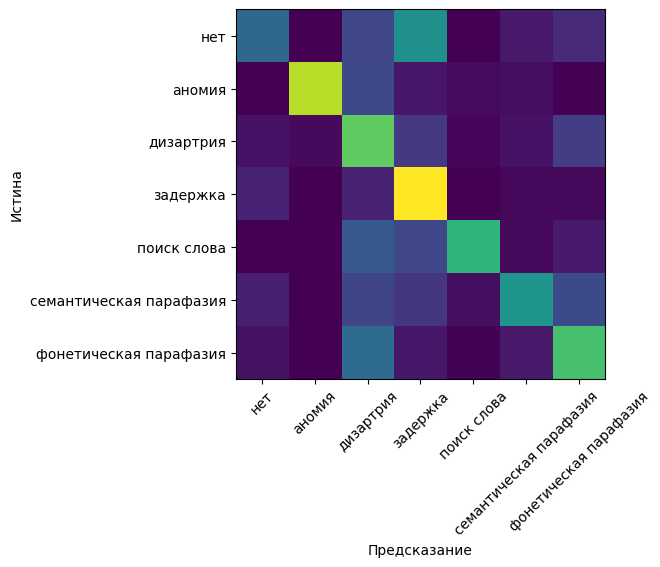

In [77]:
evaluate_T(ovovn_classifier_T)

In [79]:
for max_depth in range(1, 14):
    ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
        )
    print(max_depth,
          evaluate_T(ovovn_classifier_T,
                     supress_print = True,
                     supress_plot = True))


1 0.32840349105797795
2 0.45145725208160065
3 0.5460282612809564
4 0.546957008202296
5 0.5684825901129991
6 0.582323754146648
7 0.5812767698650254
8 0.5593972527316075
9 0.565802510327814
10 0.538673714446493
11 0.5521121755174531
12 0.5697565583332951
13 0.5269410196567147


In [80]:
ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=6, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
        )

5it [00:08,  1.62s/it]

Класс			Precision	Recall		F1
нет                     0.19±0.10	0.15±0.08	0.15±0.06
аномия                  0.87±0.13	0.80±0.10	0.82±0.08
дизартрия               0.54±0.06	0.53±0.05	0.53±0.05
задержка                0.84±0.01	0.85±0.05	0.84±0.03
поиск слова             0.56±0.09	0.62±0.19	0.58±0.13
семантическая парафазия 0.51±0.03	0.44±0.08	0.47±0.04
фонетическая парафазия  0.69±0.04	0.68±0.08	0.68±0.06
По всем                 0.60±0.04	0.58±0.03	0.58±0.03


np.float64(0.582323754146648)

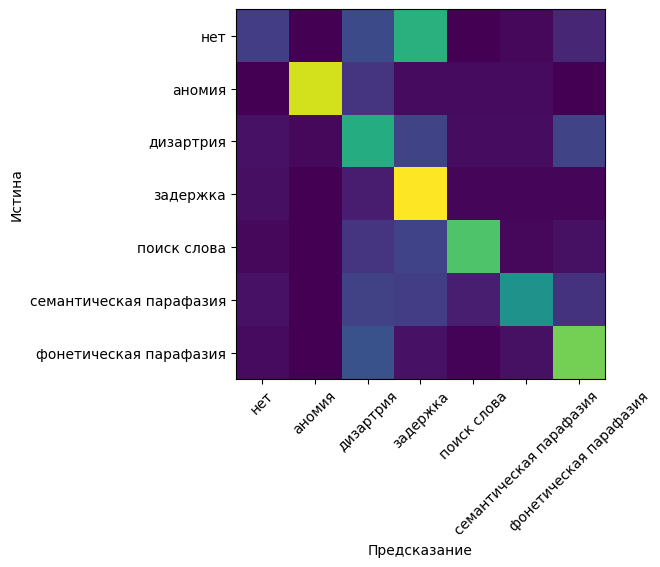

In [81]:
evaluate_T(ovovn_classifier_T)